<h1>TFM</h1>

In [24]:
# Carga de librerías
import numpy as np
import pandas as pd
from sklearn import preprocessing 
from sklearn.cluster import KMeans
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances_argmin_min

# Configuración warnings
# =================================
import warnings
warnings.filterwarnings('ignore')

In [3]:
# load dataset
df = pd.read_csv("tabla_por_distritos_limpia_derivada_integrada_v31.csv", header=0)

In [4]:
df

,codigo,nombre,Territorio - Superficie distrito [km2],Movilidad y transporte - Paradas EMT [por_km2],Movilidad y transporte - Turismos [por_1000_hab],Movilidad y transporte - Edad media turismos particulares [anos],Movilidad y transporte - Superficie aparcamiento por vivienda [m2_vivienda],Movilidad y transporte - Superficie aparcamiento por turismo [m2_turismo],Movilidad y transporte - Aparcamiento publico o de rotacion [por_1000_hab],Movilidad y transporte - Aparcamiento asociado a vados [por_1000_hab],...,Edificacion vivienda 2025 inmuebles uso | Actividad economica no residencial [por_1000_hab],Urbanismo - Parcelas urbanas pequenas <=500m2 [por_100_hab],Urbanismo - Parcelas urbanas medianas 501_10000m2 [por_100_hab],Urbanismo - Parcelas urbanas grandes >10000m2 [por_100_hab],Urbanismo - Parcelas urbanas superficie [m2_hab],Vivienda - Peso del valor del suelo sobre valor catastral total [%],Demografia - Movilidad residencial total entradas+salidas [por_1000_hab],Demografia - Balance residencial neto entradas-salidas [por_1000_hab],Recursos municipales - Dotacion municipal construida [m2_por_1000_hab],Recursos municipales - Valor patrimonial municipal [EUR_por_1000_hab]
0,__categoria__,CATEGORIA,Urbanismo e infraestructuras,Movilidad y transporte,Movilidad y transporte,Movilidad y transporte,Movilidad y transporte,Movilidad y transporte,Movilidad y transporte,Movilidad y transporte,...,Urbanismo e infraestructuras,Urbanismo e infraestructuras,Urbanismo e infraestructuras,Urbanismo e infraestructuras,Urbanismo e infraestructuras,Urbanismo e infraestructuras,Demografia,Demografia,Urbanismo e infraestructuras,Urbanismo e infraestructuras
1,1,CIUTAT VELLA,1.69,2.37,82.34,13.02,18.61,24.51,162.44,419.21,...,214.19,0.87,0.05,0,1.41,52.25,27.6,2.94,4835.26,5574028.4
2,2,L'EIXAMPLE,1.73,8.67,194.91,13.52,19.12,23.36,245.31,381.75,...,102.71,0.1,0.03,0,2.16,60.16,51.3,7.84,1730.02,2088187.36
3,3,EXTRAMURS,1.97,7.61,132.83,13.45,17.35,23.51,195.29,265.71,...,76.15,0.08,0.05,0,0.99,52.21,33.9,4.35,1062.94,531842.88
4,4,CAMPANAR,5.24,4.58,137.11,12.27,31.8,32.91,275.77,431.04,...,52.94,0.2,0.07,0.01,6.31,34.87,31.1,6.59,978.41,1588680.36
5,5,LA SAIDIA,1.94,5.67,78.53,13.51,12.64,16.37,128.69,188.89,...,63.28,0.34,0.05,0,1.26,32.54,21.3,1.83,775.89,891835.23
6,6,EL PLA DEL REAL,1.69,5.92,154.89,13.5,25.51,27.48,287.28,416.81,...,70.27,0.06,0.03,0,0.64,50.42,28.7,2.24,3089.71,4415017.26
7,7,L'OLIVERETA,1.99,5.53,127.28,13.92,12.11,15.12,186.7,172.92,...,35.66,0.08,0.06,0,2.04,31.37,44.8,6.06,1480.7,1184341.68
8,8,PATRAIX,2.87,3.48,116.05,12.71,15.02,15.74,219.22,319.84,...,63.8,0.22,0.18,0.01,5.3,30.94,23.2,2.08,954.24,1232479.57
9,9,JESUS,2.98,3.01,102.11,13.65,13.45,15.69,146.27,190.7,...,54.9,0.27,0.2,0.01,6.12,29.66,26.5,2.5,667.21,2203109.82


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Columns: 260 entries, codigo to Recursos municipales - Valor patrimonial municipal [EUR_por_1000_hab]
dtypes: str(260)
memory usage: 40.8 KB


In [6]:
 # Se eliminan columnas que tengan valor NaN
df = df.dropna(axis=1)
df = df.reset_index(drop=True)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Columns: 236 entries, codigo to Recursos municipales - Valor patrimonial municipal [EUR_por_1000_hab]
dtypes: str(236)
memory usage: 37.0 KB


In [8]:
categ = df.iloc[0] #guardamos la línea de categoría
df = df.drop(0, axis="index")

In [9]:
# Eliminamos columna de nombres que no usaremos en el algoritmo.
nombres = df['nombre'] # Guardamos la columna .
df = df.drop('nombre', axis=1) # Borramos la columna del dataframe.

codigo = df["codigo"]
df = df.drop("codigo", axis = 1)

In [11]:
# Se normalizan los datos con MinMax()
min_max_scaler = preprocessing.MinMaxScaler() 
df_escalado = min_max_scaler.fit_transform(df)
df_escalado = pd.DataFrame(df_escalado) # Hay que convertir a DF el resultado.
df_escalado = df_escalado.rename(columns = {0: 'Close', 1: 'Volume'})

In [12]:
df_escalado.head()

,Close,Volume,2,3,4,5,6,7,8,9,...,224,225,226,227,228,229,230,231,232,233
0,0.003889,0.150285,0.165967,0.441176,0.215918,0.357177,0.445156,0.870905,0.368140,0.0,...,1.000000,0.294545,0.013793,0.000000,0.021282,0.765699,0.227468,0.106936,1.000000,1.000000
1,0.005185,0.549778,0.576672,0.735294,0.226327,0.329386,0.813467,0.773505,1.000000,0.0,...,0.375567,0.014545,0.000000,0.000000,0.042012,1.000000,0.566524,0.578998,0.274489,0.308665
2,0.012962,0.482562,0.350177,0.694118,0.190204,0.333011,0.591156,0.471789,0.866426,0.0,...,0.226797,0.007273,0.013793,0.000000,0.009674,0.764514,0.317597,0.242775,0.118631,0.000000
3,0.118924,0.290425,0.365792,0.000000,0.485102,0.560174,0.948844,0.901664,0.437355,0.0,...,0.096790,0.050909,0.027586,0.333333,0.156716,0.250889,0.277539,0.458574,0.098882,0.209599
4,0.011990,0.359543,0.152067,0.729412,0.094082,0.160464,0.295156,0.272049,0.644131,0.0,...,0.154708,0.101818,0.013793,0.000000,0.017137,0.181872,0.137339,0.000000,0.051565,0.071396


Text(0, 0.5, '')

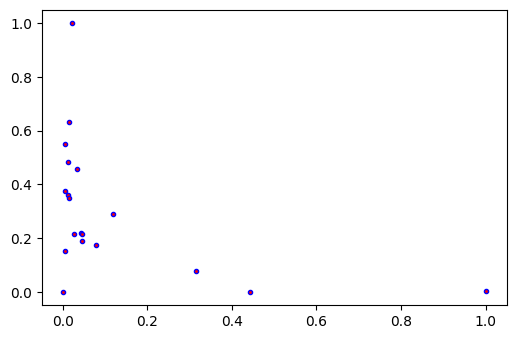

In [13]:
# Representación gráfica de los datos
x = df_escalado['Close'].values
y = df_escalado['Volume'].values
fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
ax.scatter(
    x ,
    y , 
    c = 'red',
    marker    = '.',
    edgecolor = 'blue', 
)
ax.set_title('');
plt.xlabel('')
plt.ylabel('')

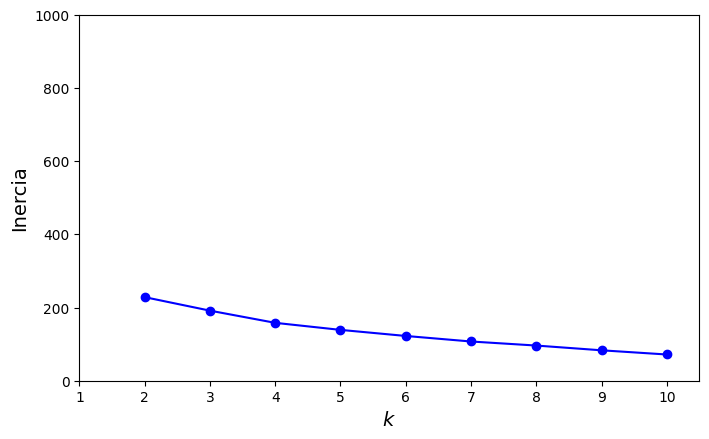

In [14]:
# definir ajuste K-medias
df_escalado = df_escalado.rename(str,axis="columns") 
kmedias_k = [KMeans(n_clusters = k, 
                    random_state = 123,
                    n_init = 25).fit(df_escalado)
             for k in range(2, 11)]
inercias = [model.inertia_ for model in kmedias_k]

# pintar inercias
plt.figure(figsize=(8, 4.75))
plt.plot(range(2, 11), inercias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.axis([1, 10.5, 0, 1000])
plt.xticks(range(1,11));
#plt.grid()
plt.show()

In [15]:

modelo_kmeans = KMeans(n_clusters=4,
                       n_init=25,
                       random_state=123)
modelo_kmeans.fit(X=df_escalado)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",25
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",123
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [16]:
y_predict = modelo_kmeans.fit_predict(X=df_escalado)
centroids = modelo_kmeans.cluster_centers_
print(centroids)

[[6.27025275e-02 2.96079053e-01 3.83402046e-01 6.43137255e-01
  1.43333333e-01 1.87369099e-01 4.52344444e-01 4.29483013e-01
  4.84088885e-01 0.00000000e+00 3.33590853e-01 5.63559322e-01
  3.47701149e-01 1.81396515e-01 7.33734519e-01 6.86700056e-01
  3.52974828e-01 4.86077482e-01 3.07942708e-01 3.86712750e-01
  6.90944882e-01 8.33041038e-01 1.73046788e-01 2.28810893e-01
  2.29166667e-01 2.58992806e-01 6.83641975e-01 5.55059524e-01
  6.22549020e-01 5.01090750e-01 6.05812221e-01 4.67466667e-01
  1.49792674e-01 6.90449438e-01 7.23207250e-01 6.90751828e-02
  7.36807726e-02 1.78903112e-01 2.50798722e-01 2.94313370e-01
  7.50927300e-01 5.44685990e-02 5.53842905e-01 1.12348375e-01
  1.49116437e-01 2.06613757e-01 7.84513154e-02 2.14188196e-01
  2.64448371e-01 1.28906250e-01 4.89100817e-01 5.83333333e-01
  6.47073237e-01 2.89062500e-01 5.03875969e-01 5.31862745e-01
  4.40963855e-01 4.75833333e-01 4.17852906e-01 3.09899813e-01
  5.34581739e-01 3.85277778e-01 4.16477273e-01 4.23502604e-01
  3.9745

In [17]:
labels = modelo_kmeans.fit_predict(df_escalado)
df['label'] = labels

In [18]:
df['cluster'] = modelo_kmeans.labels_

for cluster in df['cluster'].unique():
    cluster_df = df[df['cluster'] == cluster] 
    print(f"Cluster {cluster} Summary:\n{cluster_df.describe()}\n")

Cluster 1 Summary:
       label  cluster
count    1.0      1.0
mean     1.0      1.0
std      NaN      NaN
min      1.0      1.0
25%      1.0      1.0
50%      1.0      1.0
75%      1.0      1.0
max      1.0      1.0

Cluster 2 Summary:
       label  cluster
count    3.0      3.0
mean     2.0      2.0
std      0.0      0.0
min      2.0      2.0
25%      2.0      2.0
50%      2.0      2.0
75%      2.0      2.0
max      2.0      2.0

Cluster 0 Summary:
       label  cluster
count   12.0     12.0
mean     0.0      0.0
std      0.0      0.0
min      0.0      0.0
25%      0.0      0.0
50%      0.0      0.0
75%      0.0      0.0
max      0.0      0.0

Cluster 3 Summary:
       label  cluster
count    3.0      3.0
mean     3.0      3.0
std      0.0      0.0
min      3.0      3.0
25%      3.0      3.0
50%      3.0      3.0
75%      3.0      3.0
max      3.0      3.0



In [19]:
distances = modelo_kmeans.transform(df_escalado).min(axis=1)

# Set a threshold for anomalies (e.g., top 5% of distances)
threshold = np.percentile(distances, 95)
anomalies = df[distances > threshold]

print(f"Anomalies detected:\n{anomalies}")

Anomalies detected:
   Territorio - Superficie distrito [km2]  \
11                                   3.97   

   Movilidad y transporte - Paradas EMT [por_km2]  \
11                                           2.77   

   Movilidad y transporte - Turismos [por_1000_hab]  \
11                                             70.8   

   Movilidad y transporte - Edad media turismos particulares [anos]  \
11                                              13.97                 

   Movilidad y transporte - Superficie aparcamiento por vivienda [m2_vivienda]  \
11                                               8.03                            

   Movilidad y transporte - Superficie aparcamiento por turismo [m2_turismo]  \
11                                               9.73                          

   Movilidad y transporte - Aparcamiento publico o de rotacion [por_1000_hab]  \
11                                             152.87                           

   Movilidad y transporte - Aparcamient

In [20]:
df.loc[0] = categ
df.insert(0,"codigo", codigo)
df.insert(0, 'Nombre', nombres)

In [21]:
df

,Nombre,codigo,Territorio - Superficie distrito [km2],Movilidad y transporte - Paradas EMT [por_km2],Movilidad y transporte - Turismos [por_1000_hab],Movilidad y transporte - Edad media turismos particulares [anos],Movilidad y transporte - Superficie aparcamiento por vivienda [m2_vivienda],Movilidad y transporte - Superficie aparcamiento por turismo [m2_turismo],Movilidad y transporte - Aparcamiento publico o de rotacion [por_1000_hab],Movilidad y transporte - Aparcamiento asociado a vados [por_1000_hab],...,Urbanismo - Parcelas urbanas medianas 501_10000m2 [por_100_hab],Urbanismo - Parcelas urbanas grandes >10000m2 [por_100_hab],Urbanismo - Parcelas urbanas superficie [m2_hab],Vivienda - Peso del valor del suelo sobre valor catastral total [%],Demografia - Movilidad residencial total entradas+salidas [por_1000_hab],Demografia - Balance residencial neto entradas-salidas [por_1000_hab],Recursos municipales - Dotacion municipal construida [m2_por_1000_hab],Recursos municipales - Valor patrimonial municipal [EUR_por_1000_hab],label,cluster
1,CIUTAT VELLA,1,1.69,2.37,82.34,13.02,18.61,24.51,162.44,419.21,...,0.05,0,1.41,52.25,27.6,2.94,4835.26,5574028.4,1,1
2,L'EIXAMPLE,2,1.73,8.67,194.91,13.52,19.12,23.36,245.31,381.75,...,0.03,0,2.16,60.16,51.3,7.84,1730.02,2088187.36,2,2
3,EXTRAMURS,3,1.97,7.61,132.83,13.45,17.35,23.51,195.29,265.71,...,0.05,0,0.99,52.21,33.9,4.35,1062.94,531842.88,2,2
4,CAMPANAR,4,5.24,4.58,137.11,12.27,31.8,32.91,275.77,431.04,...,0.07,0.01,6.31,34.87,31.1,6.59,978.41,1588680.36,0,0
5,LA SAIDIA,5,1.94,5.67,78.53,13.51,12.64,16.37,128.69,188.89,...,0.05,0,1.26,32.54,21.3,1.83,775.89,891835.23,0,0
6,EL PLA DEL REAL,6,1.69,5.92,154.89,13.5,25.51,27.48,287.28,416.81,...,0.03,0,0.64,50.42,28.7,2.24,3089.71,4415017.26,2,2
7,L'OLIVERETA,7,1.99,5.53,127.28,13.92,12.11,15.12,186.7,172.92,...,0.06,0,2.04,31.37,44.8,6.06,1480.7,1184341.68,0,0
8,PATRAIX,8,2.87,3.48,116.05,12.71,15.02,15.74,219.22,319.84,...,0.18,0.01,5.3,30.94,23.2,2.08,954.24,1232479.57,0,0
9,JESUS,9,2.98,3.01,102.11,13.65,13.45,15.69,146.27,190.7,...,0.2,0.01,6.12,29.66,26.5,2.5,667.21,2203109.82,0,0
10,QUATRE CARRERES,10,11.32,1.24,87.19,13.74,13.92,16.34,262.66,217.91,...,0.42,0.03,16.18,28.93,23,9.77,708.2,3375876.04,0,0


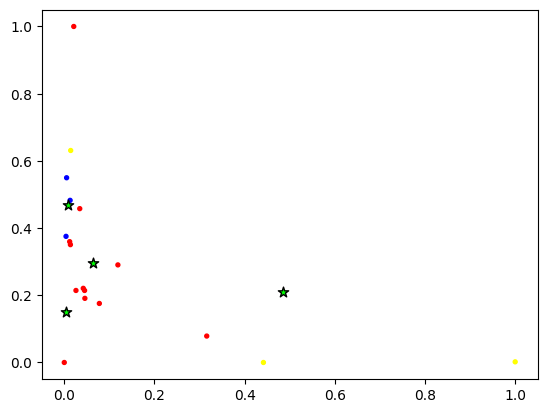

In [22]:
# Plot k-means clustering
colores=['red', 'green', 'blue', 'yellow', 'fuchsia']
asignar=[]
for row in labels:
     asignar.append(colores[row])
plt.scatter(x, y, c=asignar, s=8)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', c='lime', s=60, edgecolor = 'black') # Marcar centroides
plt.xlabel('')
plt.ylabel('')
plt.title('')
plt.show()

In [37]:
closest, _ = pairwise_distances_argmin_min(modelo_kmeans.cluster_centers_, df_escalado)

for row in closest:
    print(nombres[row+1])

JESUS
CIUTAT VELLA
L'EIXAMPLE
POBLATS DEL SUD
